In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ttc= pd.read_csv("../Git hub project/TTC delay/TTC Subway Delay Data since 2025.csv",index_col="_id",parse_dates=["Date"],date_format=["%Y/%m/%d"],)

In [3]:
ttc.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
_id,,,,,,,,,,
1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0
3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0
4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293
5,2025-01-01,02:58,Wednesday,COXWELL STATION,SUAE,0,0,NaN,BD,0


In [4]:
ttc= ttc[ttc["Vehicle"]!=0]

In [5]:
ttc.head()
ttc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10903 entries, 1 to 19232
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       10903 non-null  object
 1   Time       10903 non-null  object
 2   Day        10903 non-null  object
 3   Station    10903 non-null  object
 4   Code       10903 non-null  object
 5   Min Delay  10903 non-null  int64 
 6   Min Gap    10903 non-null  int64 
 7   Bound      10693 non-null  object
 8   Line       10897 non-null  object
 9   Vehicle    10903 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 937.0+ KB


Q1: What are the most frequent delay codes and their average durations?
Q2: What time of day and day of week see the most delays?
Q3: Which subway lines and directions (Bound) are most affected?

In [6]:
ttc_delay= ttc.groupby(by=["Code"], observed= True).agg(frequency_delay=("Code", "count"), avg_delay=("Min Delay","mean"))
ttc_delay_frequency= ttc_delay.sort_values(by="frequency_delay",ascending=False)
ttc_delay_avg=ttc_delay.sort_values(by="avg_delay",ascending=False)

<Figure size 14000x13000 with 0 Axes>

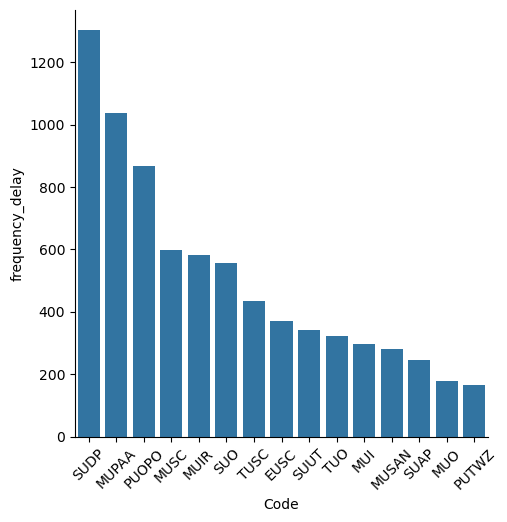

In [7]:
plt.figure(figsize=(140,130))
sns.catplot(kind="bar", data=ttc_delay_frequency.head(15),x="Code", y="frequency_delay")
plt.xticks(rotation=45)
plt.show()

<Figure size 14000x13000 with 0 Axes>

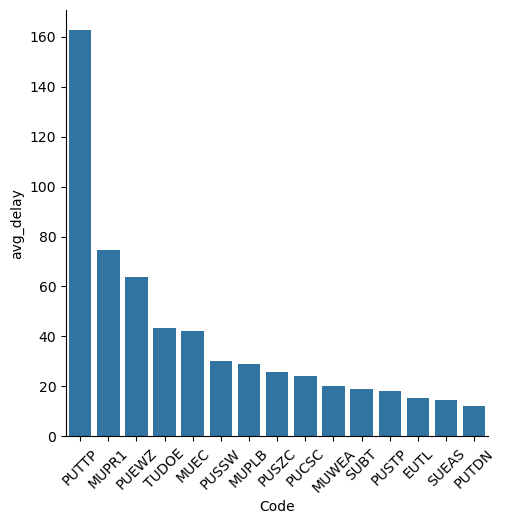

In [8]:
plt.figure(figsize=(140,130))
sns.catplot(kind="bar", data=ttc_delay_avg.head(15),x="Code", y="avg_delay")
plt.xticks(rotation=45)
plt.show()

In [9]:
ttc.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
_id,,,,,,,,,,
1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293
6,2025-01-01,07:59,Wednesday,DONLANDS STATION,TUNOA,5,10,W,BD,5000
7,2025-01-01,08:13,Wednesday,BLOOR STATION,PUTR,9,0,S,YU,5836
8,2025-01-01,08:15,Wednesday,BLOOR STATION,PUTR,5,0,N,YU,5706


In [204]:
ttc_station= ttc.groupby(by="Station",observed=True).agg(total_count_station=("Min Delay","count"),total_delay_station=("Min Delay","sum"))

print("The maximum delay occurs on",ttc_station["total_count_station"].idxmax(),". As of today the station faced",ttc_station["total_count_station"].max(), "delays.")
print("Top 10 stations with most frequent delays are the following:",ttc_station["total_count_station"].nlargest(n=10),sep="\n")



The maximum delay occurs on KENNEDY BD STATION . As of today the station faced 474 delays.
Top 10 stations with most frequent delays are the following:
Station
KENNEDY BD STATION       474
KIPLING STATION          453
FINCH STATION            370
BLOOR STATION            362
WARDEN STATION           330
WILSON STATION           288
EGLINTON STATION         260
KEELE STATION            249
YONGE BD STATION         238
VICTORIA PARK STATION    233
Name: total_count_station, dtype: int64


In [207]:
print("The",ttc_station["total_delay_station"].idxmax()," station has maximum total delay time of",ttc_station["total_delay_station"].max(), "minutes.")
print("Top 10 stations with most total delays are the following:",ttc_station["total_delay_station"].nlargest(n=10),sep="\n")

The EGLINTON STATION  station has maximum total delay time of 2302 minutes.
Top 10 stations with most total delays are the following:
Station
EGLINTON STATION         2302
SHEPPARD WEST STATION    1772
KIPLING STATION          1700
KENNEDY BD STATION       1632
WILSON STATION           1472
FINCH STATION            1469
LAWRENCE STATION         1373
BLOOR STATION            1326
UNION STATION            1164
DAVISVILLE STATION       1129
Name: total_delay_station, dtype: int64


In [14]:
ttc.head()

,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
_id,,,,,,,,,,
1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
4,2025-01-01,02:58,Wednesday,KEELE STATION,EUSC,0,0,W,BD,5293
6,2025-01-01,07:59,Wednesday,DONLANDS STATION,TUNOA,5,10,W,BD,5000
7,2025-01-01,08:13,Wednesday,BLOOR STATION,PUTR,9,0,S,YU,5836
8,2025-01-01,08:15,Wednesday,BLOOR STATION,PUTR,5,0,N,YU,5706


In [15]:
ttc["DateTime"]= pd.to_datetime(ttc["Date"]+ " " + ttc["Time"])

In [16]:
ttc["Hours"]= ttc["DateTime"].dt.hour
ttc["Month"]= ttc["DateTime"].dt.month_name()
ttc["Minutes"]= ttc["DateTime"].dt.minute

The most busiest hours for delay is the following with total delay time:
       total_delay
Hours             
5             3543


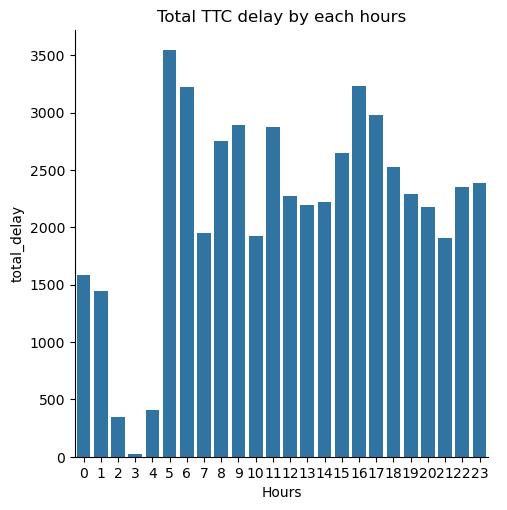

<Figure size 2000x1500 with 0 Axes>

In [98]:
#Most busiest Hour
a= ttc.groupby(by="Hours",observed=True).agg(total_delay = ("Min Delay","sum"))
most_busy_hour= a.iloc[a.idxmax()]
print("The most busiest hours for delay is the following with total delay time:",most_busy_hour,sep="\n")

sns.catplot(kind="bar", data=a,x="Hours",y="total_delay")
plt.title(label="Total TTC delay by each hours")
plt.figure(figsize=(20,15))
plt.show()

The most busiest day for delay is the following with total delay time:
Day            Tuesday
total_delay       8244
Name: 5, dtype: object


Text(0.5, 1.0, 'Total TTC delay by each day')

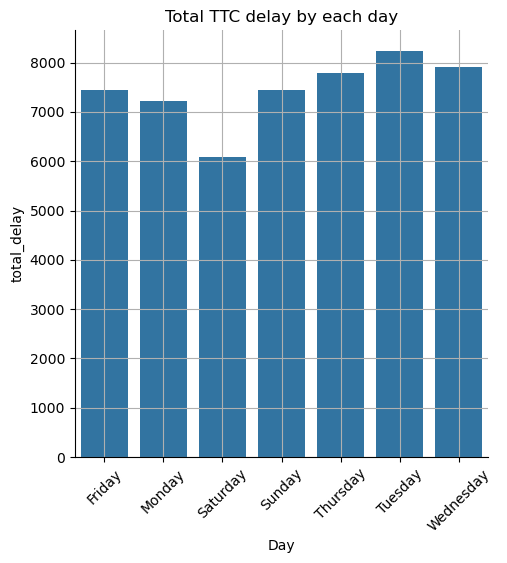

In [120]:
#Most busiest Day
b= ttc.groupby(by="Day",observed=True,as_index=False).agg(total_delay = ("Min Delay","sum"))
most_busy_day= b.iloc[b["total_delay"].idxmax()]
print("The most busiest day for delay is the following with total delay time:",most_busy_day,sep="\n")

sns.catplot(kind="bar", data=b,x="Day",y="total_delay")
plt.grid()
plt.xticks(rotation=45)
plt.title(label="Total TTC delay by each day")

<Axes: xlabel='Day', ylabel='Hours'>

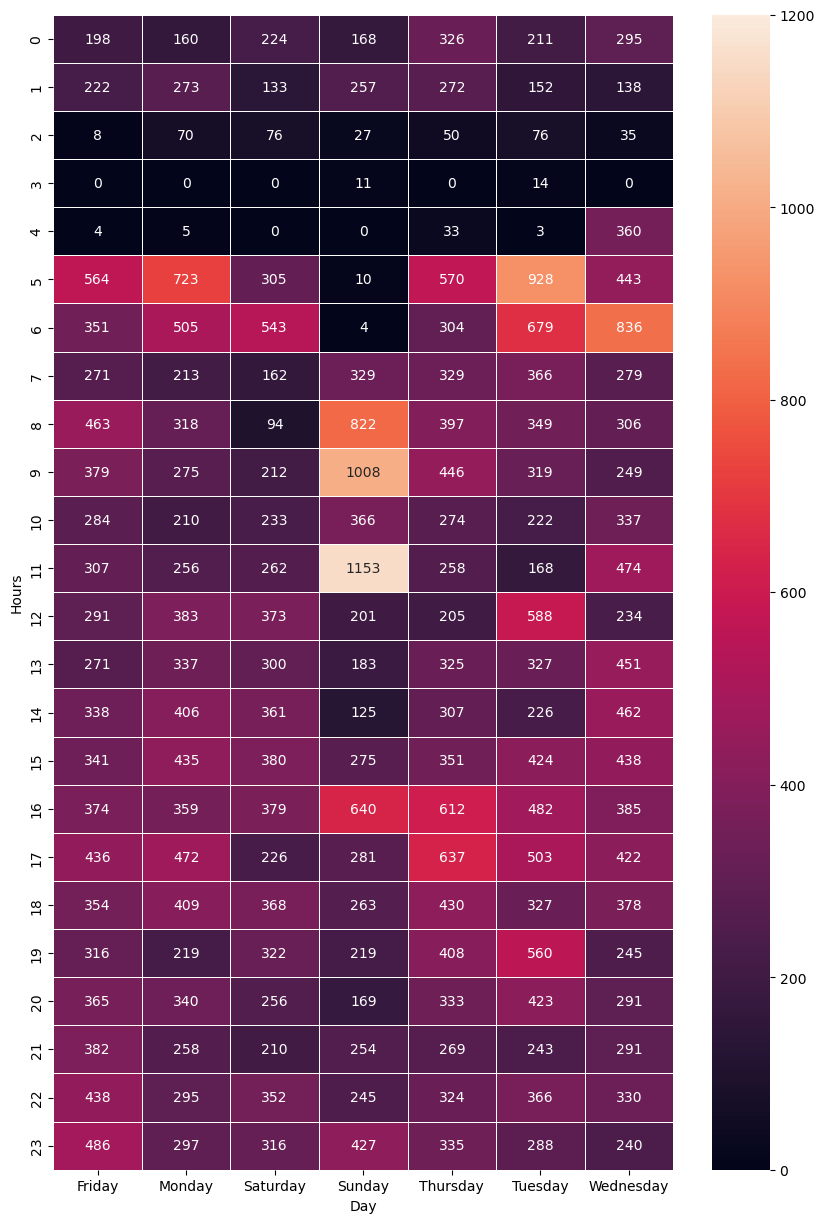

In [124]:
# Heatmap between Hours and Day

c= ttc.pivot_table(index= ["Hours"],columns="Day",values="Min Delay",aggfunc="sum",)
c
plt.figure(figsize=(10,15))
sns.heatmap(data=c,linewidths=0.5,vmin=0, vmax=1200, annot=True,fmt="d")

In [175]:
ttc.head()
ttc_line= ttc.groupby(by=["Line", "Bound"],observed=True).agg(total_count= ("Line","count"),total_delay= ("Min Delay","sum"))

ttc_line["avg_delay_per_event"]= ttc_line["total_delay"]/ttc_line["total_count"]
print(ttc_line)
print("The maximum total count of delay events occurs on",ttc_line["total_count"].idxmax(),"line and Bound respectively.","They have total number of delay event=",ttc_line["total_count"].max())
print("The maximum total delay time occurs on",ttc_line["total_delay"].idxmax(),"line and Bound respectively.""They have total delay of",ttc_line["total_count"].max(),"minutes.")
print("However, if we calculate the average delay time for each event,",ttc_line["avg_delay_per_event"].idxmax(),"has largest average delay time for each delay event. You can expect",ttc_line["avg_delay_per_event"].max(),"minutes delay per event.")

            total_count  total_delay  avg_delay_per_event
Line Bound                                               
BD   E             2503        10828             4.326009
     N                9           17             1.888889
     S                3            3             1.000000
     W             2391         8969             3.751150
SHP  E              258          958             3.713178
     N                2           16             8.000000
     S                1           11            11.000000
     W              248         1270             5.120968
YU   E               11           63             5.727273
     N             2453        14439             5.886262
     S             2809        15202             5.411890
     W                3            8             2.666667
The maximum total count of delay events occurs on ('YU', 'S') line and Bound respectively. They have total number of delay event= 2809
The maximum total delay time occurs on ('YU', 'S') li

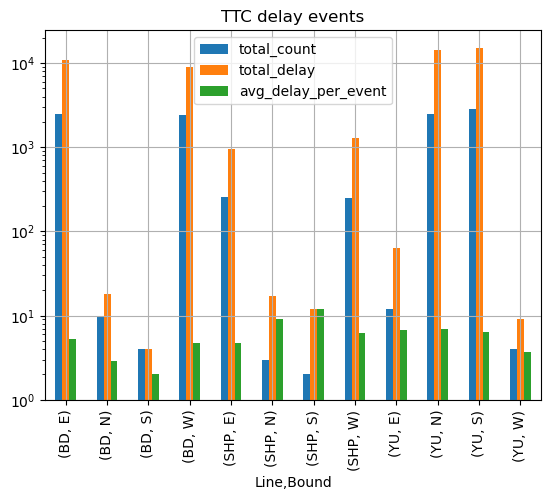

In [190]:
ttc_line.plot(kind="bar",title="TTC delay events",log= True,)
plt.grid()